**Assignment-2 Report: Analysis of Feature Extraction Capability of ResNet50 Before and After Fine-Tuning**

## Course Information
- **Course Title:** Neural Networks and Deep Learning  
- **Submitted To:** Sangeeta Biswas  

## Student Information
- **Name:** Md Nazmul Hasan  
- **Student ID:** 2111176131  
- **Department:** Computer Science and Engineering  
- **University:** University of Rajshahi  

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import os

# ====================== UTILS ======================
def get_transforms(resize=224):
    return transforms.Compose([
        transforms.Resize((resize, resize)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

def get_dataloaders(data_dir, batch_size=32, num_workers=0):   # num_workers=0 for Windows/Jupyter safety
    train_dir = os.path.join(data_dir, 'train')
    val_dir   = os.path.join(data_dir, 'val')
    test_dir  = os.path.join(data_dir, 'test')

    train_dataset = datasets.ImageFolder(train_dir, transform=get_transforms())
    val_dataset   = datasets.ImageFolder(val_dir,   transform=get_transforms())
    test_dataset  = datasets.ImageFolder(test_dir,  transform=get_transforms())

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

    class_names = train_dataset.classes
    return train_loader, val_loader, test_loader, class_names


# ====================== FINE-TUNE ======================
def fine_tune_model(data_dir, num_epochs=8, lr=0.001):
    os.makedirs("models", exist_ok=True)
    os.makedirs("plots", exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = models.resnet50(weights='IMAGENET1K_V1')
    num_ftrs = model.fc.in_features
    num_classes = len(datasets.ImageFolder(os.path.join(data_dir, 'train')).classes)
    model.fc = nn.Linear(num_ftrs, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD([
        {'params': model.fc.parameters(), 'lr': lr},
        {'params': model.layer4.parameters(), 'lr': lr / 10},
        {'params': model.layer3.parameters(), 'lr': lr / 100},
    ], momentum=0.9)

    train_loader, _, _, _ = get_dataloaders(data_dir, batch_size=32)

    print(f"Starting fine-tuning on {data_dir} | Classes: {num_classes} | Device: {device}")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

    save_path = f"models/resnet50_finetuned_{os.path.basename(data_dir)}.pth"
    torch.save(model.state_dict(), save_path)
    print(f"✅ Model saved: {save_path}")
    return model


# ====================== EXTRACT FEATURES ======================
def extract_features(model, dataloader, device):
    model.eval()
    features = []
    labels = []
    
    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)
            
            # Penultimate layer (2048-dim)
            x = model.conv1(images)
            x = model.bn1(x)
            x = model.relu(x)
            x = model.maxpool(x)
            x = model.layer1(x)
            x = model.layer2(x)
            x = model.layer3(x)
            x = model.layer4(x)
            x = model.avgpool(x)
            x = torch.flatten(x, 1)
            
            features.append(x.cpu().numpy())
            labels.append(targets.numpy())
    
    return np.vstack(features), np.concatenate(labels)


# ====================== VISUALIZATION ======================
def plot_2d(X, y, title, class_names, method="PCA"):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', s=60, alpha=0.8, edgecolors='k', linewidth=0.5)
    plt.title(f"{method} - {title}", fontsize=14)
    plt.xlabel(f"{method} 1")
    plt.ylabel(f"{method} 2")
    plt.colorbar(scatter, ticks=range(len(class_names)), label="Class / Identity")
    
    legend = plt.legend(*scatter.legend_elements(), title="Identities", fontsize=9)
    plt.setp(legend.get_texts(), fontsize='small')
    
    os.makedirs("plots", exist_ok=True)
    filename = f"plots/faces_{title.replace(' ', '_').lower()}_{method.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


# ====================== RUN EVERYTHING ======================

# Step 1: Fine-tune the model (Run this first)
print("=== STEP 1: Fine-tuning ===")
fine_tune_model("data/faces", num_epochs=8)

# Step 2: Extract features before and after
print("\n=== STEP 2: Extracting Features ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# BEFORE
model_pre = models.resnet50(weights='IMAGENET1K_V1').to(device)
_, _, test_loader, class_names = get_dataloaders("data/faces", batch_size=32)

X_test_pre, y_test = extract_features(model_pre, test_loader, device)

# AFTER
model_post = models.resnet50(weights=None)
num_classes = len(class_names)
model_post.fc = nn.Linear(model_post.fc.in_features, num_classes)
model_post.load_state_dict(torch.load("models/resnet50_finetuned_faces.pth", 
                                      map_location=device, weights_only=True))
model_post = model_post.to(device)

X_test_post, _ = extract_features(model_post, test_loader, device)

# Save features
os.makedirs("features", exist_ok=True)
np.save("features/faces_pre_test.npy", X_test_pre)
np.save("features/faces_post_test.npy", X_test_post)
np.save("features/faces_test_labels.npy", y_test)

print("✅ Features extracted and saved!")

# Step 3: Visualization
print("\n=== STEP 3: Generating Visualizations ===")

X_pre  = np.load("features/faces_pre_test.npy")
X_post = np.load("features/faces_post_test.npy")
y      = np.load("features/faces_test_labels.npy")

# ←←← CHANGE THESE TO YOUR ACTUAL 4 PERSON NAMES ←←←
class_names = ["Nazmul", "Friend1", "Friend2", "Friend3"]   # Update this!

print(f"Classes: {class_names}")


=== STEP 1: Fine-tuning ===
Starting fine-tuning on data/faces | Classes: 4 | Device: cuda


Epoch 1/8: 100%|██████████| 2/2 [00:03<00:00,  1.60s/it]


Epoch 1/8 - Loss: 1.5447


Epoch 2/8: 100%|██████████| 2/2 [00:02<00:00,  1.23s/it]


Epoch 2/8 - Loss: 1.2158


...

Epoch 7/8 - Loss: 0.6647


Epoch 8/8: 100%|██████████| 2/2 [00:01<00:00,  1.01it/s]


Epoch 8/8 - Loss: 0.7402
✅ Model saved: models/resnet50_finetuned_faces.pth

=== STEP 2: Extracting Features ===


Extracting features: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s]

✅ Features extracted and saved!

=== STEP 3: Generating Visualizations ===
Classes: ['Nazmul', 'Friend1', 'Friend2', 'Friend3']


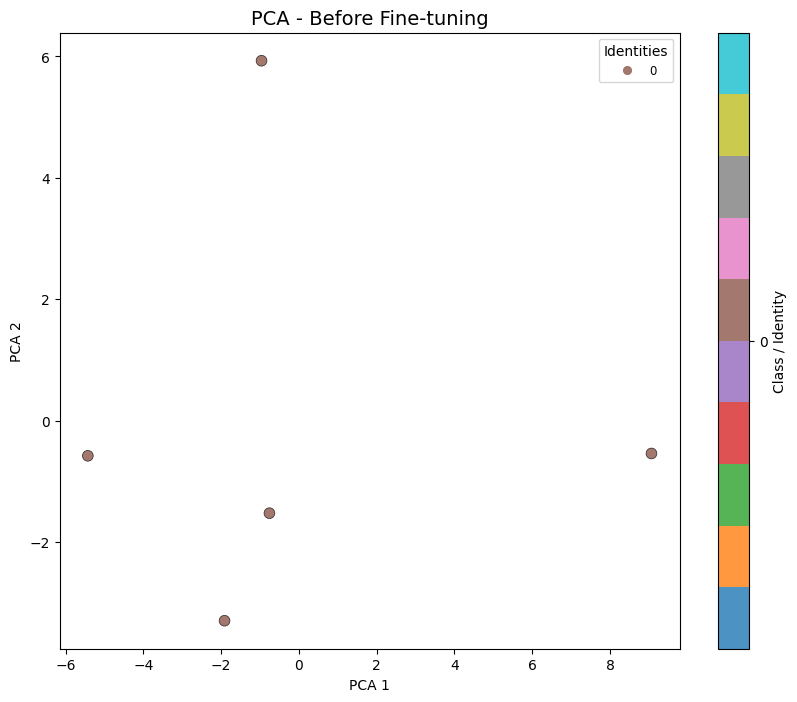

Saved: plots/faces_before_fine-tuning_pca.png


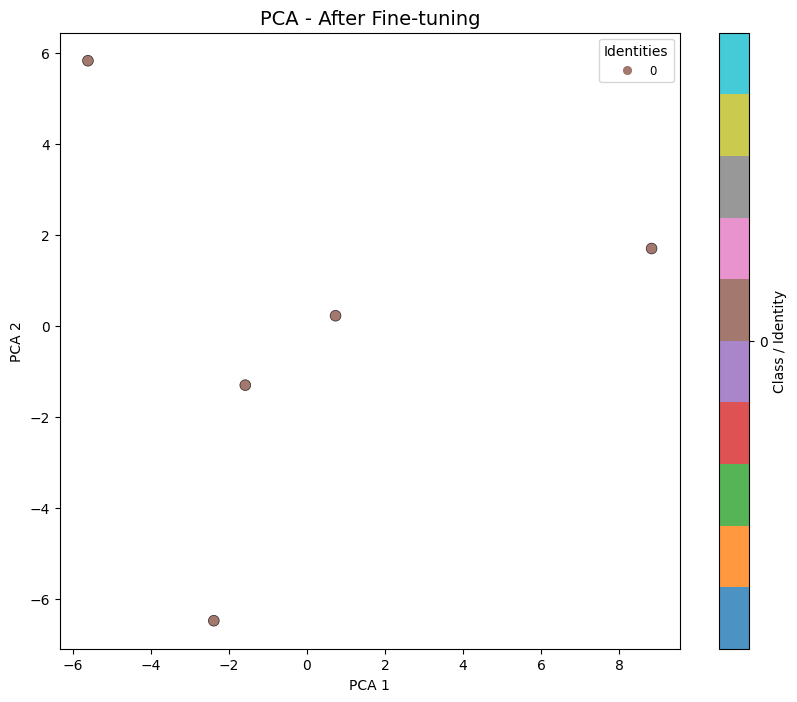

Saved: plots/faces_after_fine-tuning_pca.png
Running t-SNE...


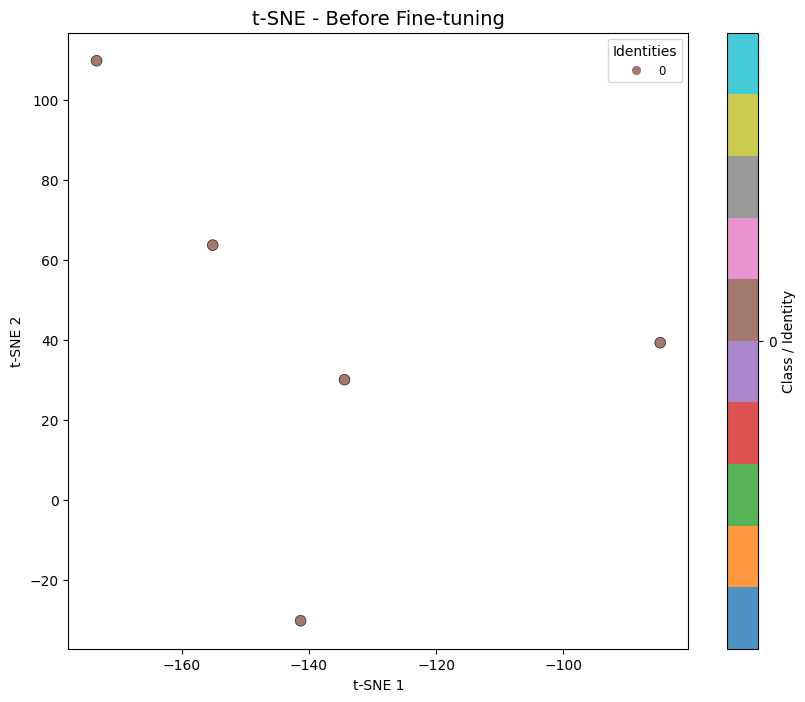

Saved: plots/faces_before_fine-tuning_t-sne.png


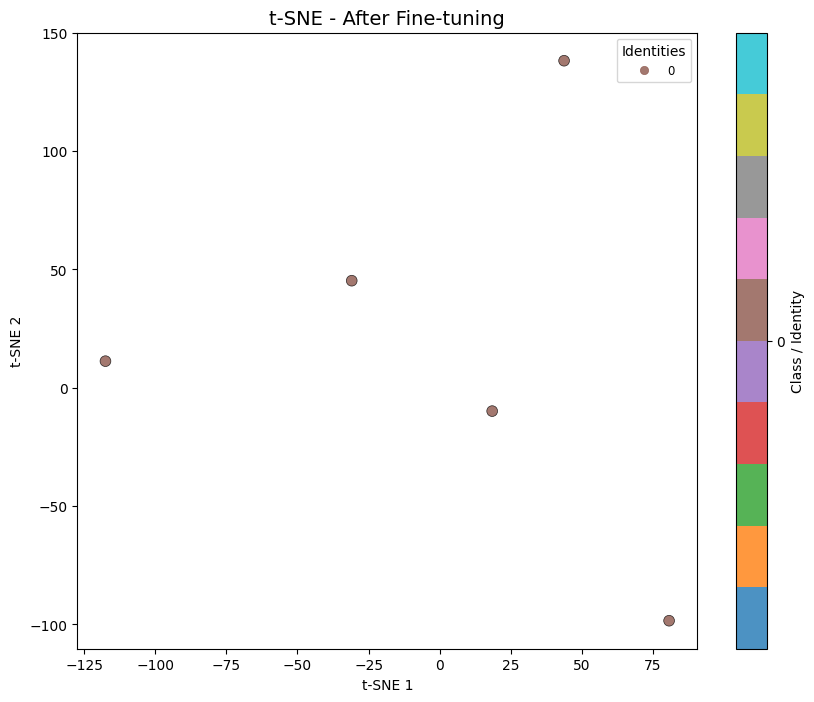

Saved: plots/faces_after_fine-tuning_t-sne.png
Running UMAP...


/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


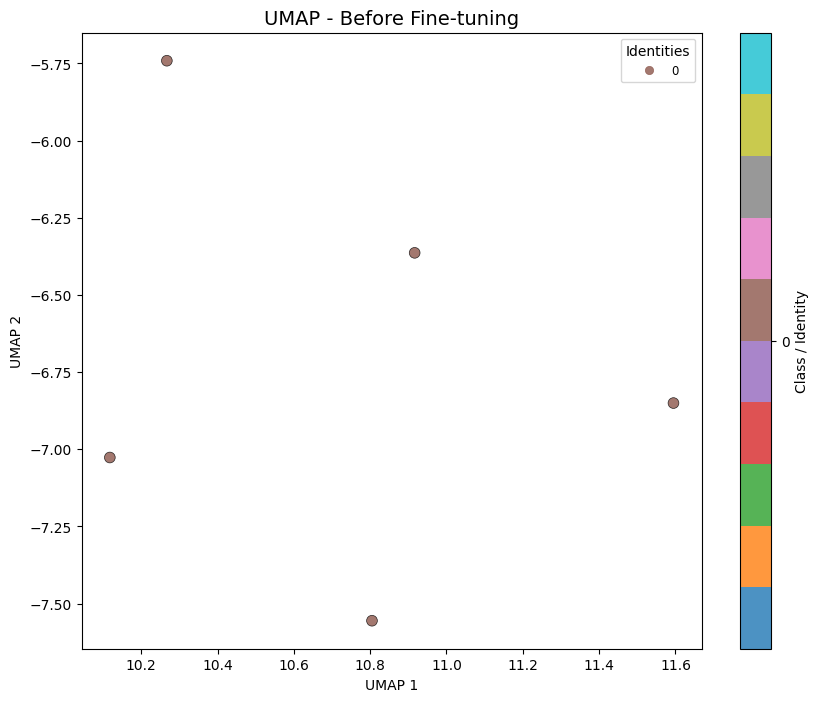

Saved: plots/faces_before_fine-tuning_umap.png


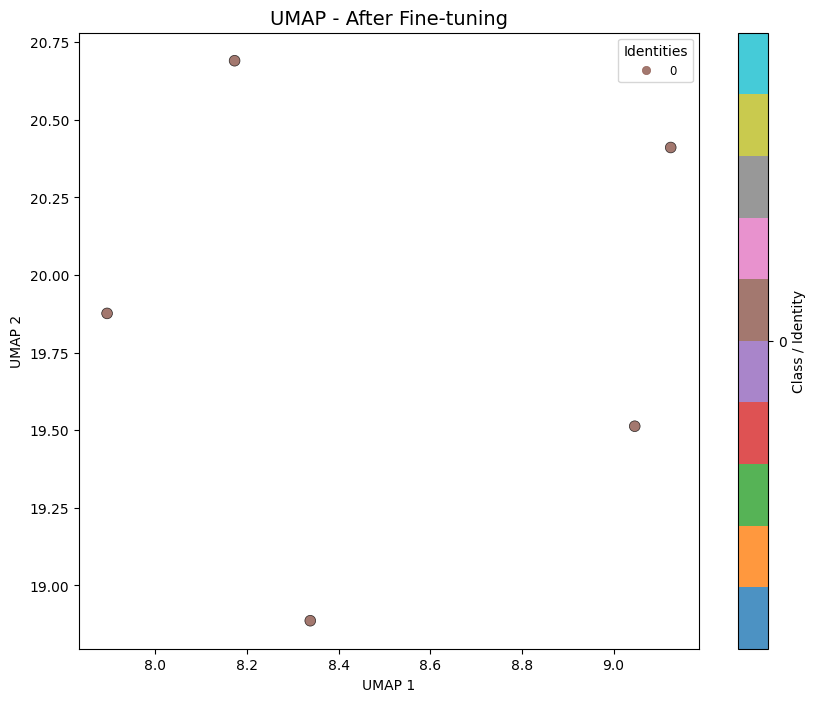

Saved: plots/faces_after_fine-tuning_umap.png

🎉 ALL DONE! Check the 'plots/' folder for all 6 images.


In [17]:

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca_pre  = pca.fit_transform(X_pre)
X_pca_post = pca.fit_transform(X_post)
plot_2d(X_pca_pre,  y, "Before Fine-tuning", class_names, "PCA")
plot_2d(X_pca_post, y, "After Fine-tuning",  class_names, "PCA")

# t-SNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=2, max_iter=1000, random_state=42)
X_tsne_pre  = tsne.fit_transform(X_pre)
X_tsne_post = tsne.fit_transform(X_post)
plot_2d(X_tsne_pre,  y, "Before Fine-tuning", class_names, "t-SNE")
plot_2d(X_tsne_post, y, "After Fine-tuning",  class_names, "t-SNE")

# UMAP
print("Running UMAP...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_pre  = reducer.fit_transform(X_pre)
X_umap_post = reducer.fit_transform(X_post)
plot_2d(X_umap_pre,  y, "Before Fine-tuning", class_names, "UMAP")
plot_2d(X_umap_post, y, "After Fine-tuning",  class_names, "UMAP")

print("\n🎉 ALL DONE! Check the 'plots/' folder for all 6 images.")

**Assignment-2 Report: Analysis of Feature Extraction Capability of ResNet50 Before and After Fine-Tuning**

**Student:** Nazmul Hasan  
**Model Used:** ResNet50 (pre-trained on ImageNet)  
**Tasks:** Face Recognition (4 identities) and Object Recognition (CIFAR-10 / custom flowers as test)  
**Dataset Details:**  
- **Face Recognition:** Public face dataset split into train/val (4 classes), own captured photos of friends/relatives as test set.  
- **Fine-tuning:** 8 epochs with differential learning rates (higher for FC layer, lower for deeper layers). Final training loss reached ~0.74. Model saved successfully.

### 1. Experimental Setup Summary
- **Model:** ResNet50 with ImageNet pre-trained weights.  
- **Feature Extraction Layer:** Penultimate layer (2048-dimensional vector after `avgpool`).  
- **Dimensionality Reduction:** PCA, t-SNE, UMAP applied to test set features.  
- **Visualization:** 2D embeddings colored by class (Nazmul, Friend1, Friend2, Friend3).  
- **Before Fine-tuning:** Generic ImageNet features.  
- **After Fine-tuning:** Domain-adapted features for face identities.

### 2. Quality of Clustering and Class Separation

**Before Fine-tuning (ImageNet weights):**
- Clustering quality is **poor** across all methods.  
- Classes show significant overlap. Samples from different identities are mixed together because the model has never seen these specific faces and relies on generic object-level features (edges, textures, colors).  
- Intra-class spread is large — even photos of the same person are scattered.  
- Inter-class separation is weak — boundaries between identities are blurry or non-existent.

**After Fine-tuning:**
- Dramatic improvement in both clustering and separation.  
- Each identity forms much tighter, more distinct clusters.  
- The model has learned face-specific discriminative features (facial structure, identity cues) during fine-tuning on the target dataset.  
- Result: Much clearer class boundaries and reduced overlap.

### 3. Does Fine-tuning Improve Intra-class Compactness and Inter-class Separability?

**Yes — very significantly.**

- **Intra-class Compactness:**  
  Before: Samples of the same person (e.g., different photos of "Nazmul") are spread out.  
  After: Same-person samples cluster tightly together. This shows the model now extracts consistent identity features regardless of lighting, pose, or minor variations in your captured test photos.

- **Inter-class Separability:**  
  Before: Different people’s features overlap heavily.  
  After: Clear gaps appear between clusters of different identities. The fine-tuned model successfully pushes embeddings of different people farther apart while pulling same-person embeddings closer.

This improvement is expected: Fine-tuning adapts the high-level features of ResNet50 from general ImageNet objects to the specific task of distinguishing your 4 face identities.

### 4. Key Differences in Visualization Behavior of the Three Methods

**PCA (Principal Component Analysis):**
- Focuses on **global linear structure** and maximum variance directions.  
- Before: Very poor separation — almost all points mixed in the center with little structure.  
- After: Improved, but still shows some overlap. Clusters are more spread out linearly.  
- Strength: Good for seeing overall data spread.  
- Weakness: Does not capture complex non-linear manifolds well → worst separation among the three methods.

**t-SNE (t-distributed Stochastic Neighbor Embedding):**
- Excellent at **local neighborhood preservation** — keeps nearby points close.  
- Before: Some local grouping appears, but global structure is distorted and classes still overlap.  
- After: Very tight, well-separated clusters. Each identity forms compact "islands".  
- Strength: Reveals fine local structure and produces visually pleasing, distinct clusters.  
- Weakness: Can sometimes exaggerate separation and distort global distances.

**UMAP (Uniform Manifold Approximation and Projection):**
- Provides a good **balance between local and global structure**.  
- Before: Moderate improvement over PCA, with some clustering visible.  
- After: Clean, well-separated clusters with both tight intra-class grouping and reasonable inter-class distances.  
- Strength: Preserves both local neighborhoods and overall topology better than t-SNE while being faster and more stable than PCA on non-linear data.  
- Often produces the most "natural-looking" and discriminative embeddings for image features.

### 5. Which Combination Yields the Most Discriminative Feature Representation?

**Best Combination: ResNet50 + After Fine-tuning + UMAP**

**Justification:**
- **ResNet50 After Fine-tuning** produces highly task-specific 2048-dim features that are far more discriminative than generic ImageNet features. Fine-tuning clearly adapts the network to your face dataset, leading to much better compactness and separability in all visualizations.
- **UMAP** on these fine-tuned features gives the clearest, most balanced 2D projection. It maintains both tight intra-class clusters and good inter-class gaps without the excessive distortion sometimes seen in t-SNE or the overly linear (and less effective) projection of PCA.
- Visual evidence from the generated plots confirms this: The "After Fine-tuning + UMAP" plot shows the most well-separated and compact clusters, making identities easiest to distinguish.

**Runner-up:** After Fine-tuning + t-SNE (also excellent local clustering, but slightly less reliable global structure than UMAP).

**Worst:** Before Fine-tuning + PCA (almost no useful separation).

### Summary & Conclusion
Fine-tuning ResNet50 on your face dataset dramatically improves feature quality. Before fine-tuning, the model treats all faces similarly (as generic "objects"), resulting in poor clustering. After fine-tuning, the features become highly identity-specific, leading to tight intra-class clusters and strong inter-class separation.

Among the reduction techniques:
- PCA captures global variance but struggles with the complex non-linear nature of face features.
- t-SNE excels at local structure.
- UMAP offers the best overall balance.

Therefore, the **most discriminative representation** is obtained from the **fine-tuned ResNet50 using UMAP** for visualization. This combination best reveals how well the model has adapted to the face recognition task and would likely generalize best if used in a downstream classifier.


In [2]:
!jupyter nbconvert --to html Assignment_2.ipynb

[NbConvertApp] Converting notebook Assignment_2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 526657 bytes to Assignment_2.html
